In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re 
import glob
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib import colors
import matplotlib.ticker as ticker

In [2]:
# Read in the data
cells = pd.read_csv('../data/cd34_umap_patient_updated.csv', index_col = 0)
cells.head()

,V1,209Bi_CD45,Center,161Dy_CD274_PDL1,162Dy_CD80,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,...,171Yb_CD40_asinh_coarseAlign_fineAlign,172Yb_CD141_asinh_coarseAlign_fineAlign,173Yb_CD47_Biotin_asinh_coarseAlign_fineAlign,174Yb_HLA-DR_asinh_coarseAlign_fineAlign,176Yb_CD56_asinh_coarseAlign_fineAlign,Alignment_MC_fineAlign,FlowSOM_cluster,FlowSOM_metacluster,UMAP_X,UMAP_Y
1,28753,0.0,647.607,0.000000,0.0,20,0.0,0.0,234.340,480.476,...,0.001253,1.108892,5.219315,1.683933,0.056456,1,190,8,0.866657,1.362626
2,63063,0.0,994.452,0.353601,0.0,23,0.0,0.0,250.888,436.264,...,0.057230,0.011297,4.455036,3.095641,0.978794,1,150,8,-0.343001,1.978852
3,113881,0.0,581.023,0.000000,0.0,15,0.0,0.0,203.854,371.390,...,0.136340,0.011297,5.190953,1.353130,0.678277,1,188,11,0.087462,-0.777240
4,15032,0.0,992.035,0.000000,0.0,19,0.0,0.0,135.380,196.982,...,0.001253,0.827668,4.430402,1.834134,2.356458,1,81,17,-2.044059,2.897908
5,107677,0.0,1259.680,0.000000,0.0,25,0.0,0.0,109.953,244.157,...,0.020425,0.028231,5.281482,0.591674,1.699843,2,5,2,-0.182449,0.340631


In [3]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample P26 as the patient went off trial due to participant preference
print(cells.shape)
cells = cells.loc[cells['FileName'] != 'P02_SPD_T_Cell_Panel',:]
cells = cells.loc[~cells['FileName'].str.contains('P26'),:]
# Delete the following samples as they have only a single measurement
cells = cells.loc[~cells['FileName'].str.contains('P27'),:]
cells = cells.loc[~cells['FileName'].str.contains('P15'),:]
cells['FileName'] = cells['FileName'].str.replace('P02_SPD_2_T_Cell_Panel', 'P02_SPD_T_Cell_Panel')
print(cells.shape)

(13794, 67)
(13310, 67)


In [5]:
# Fix the 'Timepoint' column in the dataframe so that I can merge it with a 
# data sheet that Julie has provided to me
cells['Timepoint'] = cells['Timepoint'].str.replace('_Control', '')
cells['Timepoint'] = cells['Timepoint'].str.replace('SPD', 'Progression')
cells['Timepoint'] = cells['Timepoint'].str.replace('_', '')
cells['Patient_timepoint'] = cells['Patient_ID'] + '_' + cells['Timepoint']
cells['Patient_timepoint'] =  cells['Patient_timepoint'].astype(str)

In [6]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx', nrows=40)
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as 
# diagnosis and clinical outcomes

diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))
outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))
outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))


In [7]:
# Use the dictionaries to add clinical outcomes to the dataframe
cells['diagnosis'] = cells['Patient_ID'].map(diagnosis_dx)
cells['outcome_6'] = cells['Patient_ID'].map(outcome_C6_dx)
cells['outcome_12'] = cells['Patient_ID'].map(outcome_C12_dx)

# Update the clinical outcomes and diagnosis columns to reflect that there are healthy samples in the sample set
diagnosis = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells['Patient_ID'], cells['diagnosis'])]        

outcome_6 = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells['Patient_ID'], cells['outcome_6'])]   

outcome_12 = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells['Patient_ID'], cells['outcome_12'])]   

cells['diagnosis'] = diagnosis
cells['outcome_6'] = outcome_6
cells['outcome_12'] = outcome_12 


In [8]:
# Create a list so that I can delete the samples where I acquired a C7D22 but the patient dropped out for
# reasons unrelated to the disease or treatment note that these patients have an NA in the outcome_12 column
to_del = []
time_to_keep = ['non-responder_2', 'responder_1', 'Healthy']
for x, y, in zip(cells['Patient_timepoint'], cells['outcome_12']):
    if x.__contains__('C7D22') & (y not in time_to_keep):
        to_del.append(x)

print(cells.shape)
cells1 = cells.loc[~cells['Patient_timepoint'].isin(to_del), :]
print(cells1.shape)

del to_del

(13310, 71)
(13068, 71)


In [9]:
# Read in new cell type dictionary
cluster_result = pd.read_csv('../data/cd34_annotation.csv')
cell_type_dict = dict(zip(cluster_result['cluster'], cluster_result['cell_type']))
cell_type_dict

cells1['cell_type'] = cells1['FlowSOM_metacluster'].map(cell_type_dict)

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_26695/2708064234.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells1['cell_type'] = cells1['FlowSOM_metacluster'].map(cell_type_dict)


In [10]:
# Read in a table which maps a cell type to a color
color_table = pd.read_excel('../data/2026_01_27_colors.xlsx')
color_dict = dict(zip(color_table['Cell_type'], color_table['Color']))
color_dict

{'Myeloid precursor': '#EEA236FF',
 'MEP': '#D43F3AFF',
 'CMP': '#5CB85CFF',
 'HSC': '#46B8DAFF',
 'GMP': '#357EBDFF',
 'CD56 pos': '#B8B8B8FF',
 'CD33 HSC': '#9632B8FF'}

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_26695/3239926327.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout(w_pad = 1, h_pad = 1)


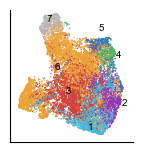

In [11]:
# Make a graph which describes the cell types found in this dataset 
plt.rcParams.update({'mathtext.default':  'regular' })
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6.1/4, 3.25/2), constrained_layout=True)
ax.scatter(x = cells1['UMAP_X'], y = cells1['UMAP_Y'], s = 1, c = cells1['cell_type'].map(color_dict), 
              linewidth = 0)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.text(s = '1', x = 1, y = -4, fontsize = 7)
ax.text(s = '2', x = 4, y = -2, fontsize = 7)
ax.text(s = '3', x = -1, y = -1, fontsize = 7)
ax.text(s = '6', x = -2, y = 1, fontsize = 7)
ax.text(s = '4', x = 3.5, y = 2, fontsize = 7)
ax.text(s = '5', x = 2, y = 4.25, fontsize = 7)
ax.text(s = '7', x = -2.75, y = 5, fontsize = 7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-5, 6)
ax.set_xlim(-6, 5)

ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel('', labelpad = -1, fontsize = 7)
ax.set_xlabel('', labelpad = 1, fontsize = 7)


plt.tight_layout(w_pad = 1, h_pad = 1)
# fig.savefig('results/layout_version_4_1.png', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)  
# fig.savefig('results/layout_version_4_1.svg', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)  
# fig.savefig('results/layout_version_4_1.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)  

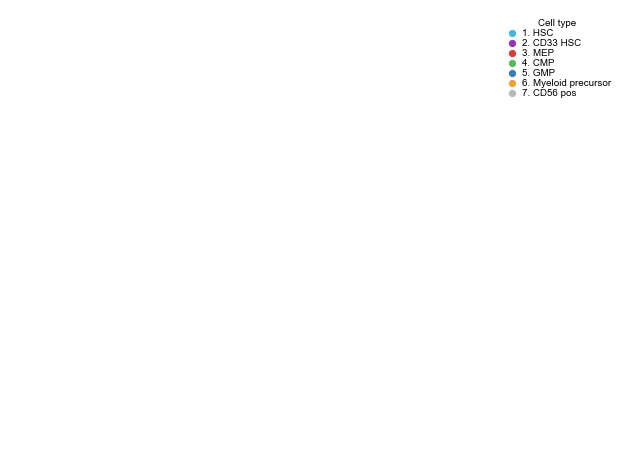

In [12]:
# Plot the legend
handles3 = []
labels = []
f3, a3 = plt.subplots()
count = 1
lab = ['HSC', 'CD33 HSC', 'MEP', 'CMP',  'GMP', 'Myeloid precursor', 'CD56 pos']
for lab in lab:
    line = a3.scatter([0],[0], label=lab, color=color_dict[lab], marker = 'o', s = 50, alpha = 1)
    handles3.append(line)    
    labels.append(str(count) +'. ' + lab)
    count +=1
plt.close(f3)

fig, ax = plt.subplots()
ax.legend(handles = handles3, labels = labels,
          title = 'Cell type', 
          ncol = 1, columnspacing = 0.8, handletextpad=0, fontsize = 7, frameon = False,
           title_fontsize = 7
          , markerscale = 0.6, labelspacing=0.1)

ax.axis('off')
plt.tight_layout(w_pad = 0.1, h_pad = 0.5)
# fig.savefig('results/layout_version_4_1_legend.png', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)
# fig.savefig('results/layout_version_4_1_legend.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)
# fig.savefig('results/layout_version_4_1_legend.svg', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)